Using selected dims file:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_rawdim_selected_dims.csv

Detected correlation file:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_rawdim_observable_spearman.csv

Selected dims preview:


,city,raw_dim
0,Houston,A02
1,Houston,A04
2,Houston,A07
3,Houston,A16
4,Houston,A17



Cities found: ['Houston', 'Phoenix']

Counts:
Houston selected dims: 15
Phoenix selected dims: 16
Shared dims: 3
Houston unique dims: 12
Phoenix unique dims: 13


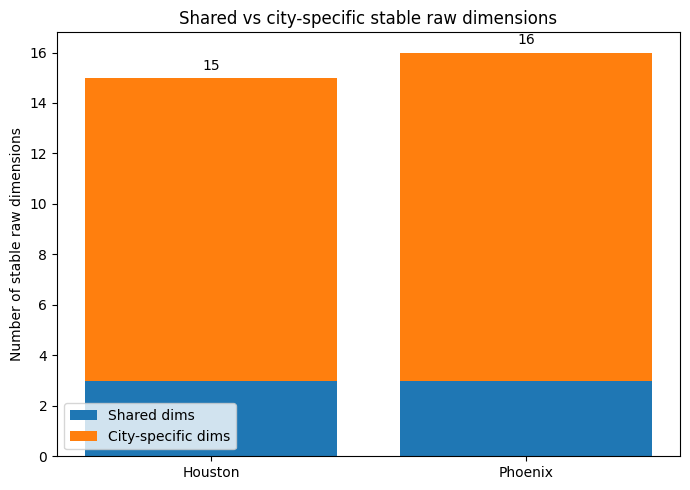


Saved files:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_shared_vs_unique_rawdims_summary.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_shared_rawdim_presence.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_shared_rawdim_best_links.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_shared_vs_unique_rawdims.png
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_shared_vs_unique_rawdims_note.txt

===== Summary =====


,city,n_selected_dims,n_shared_dims,n_city_unique_dims,shared_dims,city_unique_dims
0,Houston,15,3,12,"A04, A22, A59","A02, A07, A16, A17, A25, A28, A31, A32, A34, A..."
1,Phoenix,16,3,13,"A04, A22, A59","A01, A03, A09, A19, A26, A40, A44, A47, A52, A..."



===== Presence table =====


,raw_dim,Houston,Phoenix,group
0,A01,False,True,Phoenix_only
1,A02,True,False,Houston_only
2,A03,False,True,Phoenix_only
3,A04,True,True,shared
4,A07,True,False,Houston_only
5,A09,False,True,Phoenix_only
6,A16,True,False,Houston_only
7,A17,True,False,Houston_only
8,A19,False,True,Phoenix_only
9,A22,True,True,shared



===== Shared-dim best observable links =====


,raw_dim,Houston_best_var,Houston_r,Houston_abs_r,Houston_n,Phoenix_best_var,Phoenix_r,Phoenix_abs_r,Phoenix_n
0,A04,median_household_income_clean,0.193332,0.193332,645,median_household_income_clean,0.257794,0.257794,368
1,A22,median_household_income_clean,0.327665,0.327665,645,lst_c,-0.471270,0.471270,373
2,A59,lst_c,-0.164317,0.164317,654,hi_minus_lst,0.626842,0.626842,332


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# paths
# =========================================================
ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUT = ROOT / "outputs/pilot/alphaearth"
OUT.mkdir(parents=True, exist_ok=True)

selected_csv = OUT / "city_rawdim_selected_dims.csv"
if not selected_csv.exists():
    raise FileNotFoundError(f"Missing file: {selected_csv}")

print("Using selected dims file:")
print(selected_csv)

# try to find full rawdim-observable correlation file
corr_candidates = sorted(list(OUT.glob("*observable*spearman*.csv")) + list(OUT.glob("*rawdim*spearman*.csv")))
corr_file = None
for fp in corr_candidates:
    if "pair_summary" not in fp.name.lower():
        corr_file = fp
        break

print("\nDetected correlation file:")
print(corr_file if corr_file is not None else "Not found (will skip shared-dim best-link table)")

# =========================================================
# helper: normalize columns
# =========================================================
def normalize_selected_cols(df):
    rename = {}
    for c in df.columns:
        lc = c.lower().strip()
        if lc == "city":
            rename[c] = "city"
        elif ("selected" in lc and "dim" in lc) or lc in {"raw_dim", "embedding_dim", "dim"}:
            rename[c] = "raw_dim"
    out = df.rename(columns=rename).copy()
    if "city" not in out.columns or "raw_dim" not in out.columns:
        raise KeyError(f"Could not find city/raw_dim columns in selected dims file. Columns: {list(df.columns)}")
    return out

def normalize_corr_cols(df):
    rename = {}
    for c in df.columns:
        lc = c.lower().strip()
        if lc == "city":
            rename[c] = "city"
        elif lc in {"raw_dim", "embedding_dim", "dim"}:
            rename[c] = "raw_dim"
        elif "observable" in lc and "var" in lc:
            rename[c] = "variable"
        elif lc == "variable":
            rename[c] = "variable"
        elif lc == "spearman_r":
            rename[c] = "spearman_r"
        elif lc == "abs_spearman_r":
            rename[c] = "abs_spearman_r"
        elif lc == "n":
            rename[c] = "n"
    out = df.rename(columns=rename).copy()
    required = {"city", "raw_dim"}
    if not required.issubset(out.columns):
        raise KeyError(f"Could not normalize correlation file columns. Columns: {list(df.columns)}")
    return out

# =========================================================
# load selected dims
# =========================================================
sel = pd.read_csv(selected_csv).copy()
sel = normalize_selected_cols(sel)

sel["city"] = sel["city"].astype(str).str.strip()
sel["raw_dim"] = sel["raw_dim"].astype(str).str.strip()

sel = sel.dropna(subset=["city", "raw_dim"]).drop_duplicates().copy()

print("\nSelected dims preview:")
display(sel.head())

# =========================================================
# city sets
# =========================================================
cities = sorted(sel["city"].unique().tolist())
print("\nCities found:", cities)

if not {"Houston", "Phoenix"}.issubset(set(cities)):
    raise ValueError(f"Expected Houston and Phoenix in selected dims file, got: {cities}")

hou_dims = sorted(set(sel.loc[sel["city"] == "Houston", "raw_dim"]))
phx_dims = sorted(set(sel.loc[sel["city"] == "Phoenix", "raw_dim"]))

shared_dims = sorted(set(hou_dims) & set(phx_dims))
hou_unique = sorted(set(hou_dims) - set(phx_dims))
phx_unique = sorted(set(phx_dims) - set(hou_dims))
all_dims = sorted(set(hou_dims) | set(phx_dims))

print("\nCounts:")
print("Houston selected dims:", len(hou_dims))
print("Phoenix selected dims:", len(phx_dims))
print("Shared dims:", len(shared_dims))
print("Houston unique dims:", len(hou_unique))
print("Phoenix unique dims:", len(phx_unique))

# =========================================================
# summary table
# =========================================================
summary_df = pd.DataFrame({
    "city": ["Houston", "Phoenix"],
    "n_selected_dims": [len(hou_dims), len(phx_dims)],
    "n_shared_dims": [len(shared_dims), len(shared_dims)],
    "n_city_unique_dims": [len(hou_unique), len(phx_unique)],
    "shared_dims": [", ".join(shared_dims), ", ".join(shared_dims)],
    "city_unique_dims": [", ".join(hou_unique), ", ".join(phx_unique)],
})

summary_csv = OUT / "city_shared_vs_unique_rawdims_summary.csv"
summary_df.to_csv(summary_csv, index=False)

# =========================================================
# presence table
# =========================================================
presence_rows = []
for d in all_dims:
    in_hou = d in hou_dims
    in_phx = d in phx_dims
    if in_hou and in_phx:
        group = "shared"
    elif in_hou:
        group = "Houston_only"
    else:
        group = "Phoenix_only"
    presence_rows.append({
        "raw_dim": d,
        "Houston": in_hou,
        "Phoenix": in_phx,
        "group": group
    })

presence_df = pd.DataFrame(presence_rows)
presence_csv = OUT / "city_shared_rawdim_presence.csv"
presence_df.to_csv(presence_csv, index=False)

# =========================================================
# optional: shared dim best observable links
# =========================================================
shared_link_df = pd.DataFrame()

if corr_file is not None:
    corr = pd.read_csv(corr_file).copy()
    corr = normalize_corr_cols(corr)

    # fill optional columns
    if "variable" not in corr.columns:
        # maybe there is another usable column
        possible_var_cols = [c for c in corr.columns if "var" in c.lower()]
        if len(possible_var_cols) > 0:
            corr["variable"] = corr[possible_var_cols[0]]
        else:
            corr["variable"] = np.nan

    if "spearman_r" not in corr.columns:
        raise KeyError(f"Correlation file missing spearman_r. Columns: {list(corr.columns)}")

    if "abs_spearman_r" not in corr.columns:
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

    if "n" not in corr.columns:
        corr["n"] = np.nan

    corr["city"] = corr["city"].astype(str).str.strip()
    corr["raw_dim"] = corr["raw_dim"].astype(str).str.strip()

    corr_shared = corr[corr["raw_dim"].isin(shared_dims)].copy()

    if len(corr_shared) > 0:
        best_links = (
            corr_shared
            .sort_values(["city", "raw_dim", "abs_spearman_r"], ascending=[True, True, False])
            .groupby(["city", "raw_dim"], as_index=False)
            .head(1)
            .copy()
        )

        best_links = best_links[["city", "raw_dim", "variable", "spearman_r", "abs_spearman_r", "n"]].copy()

        # pivot to compare Houston vs Phoenix side by side
        hou_best = best_links[best_links["city"] == "Houston"].copy()
        hou_best = hou_best.rename(columns={
            "variable": "Houston_best_var",
            "spearman_r": "Houston_r",
            "abs_spearman_r": "Houston_abs_r",
            "n": "Houston_n"
        }).drop(columns=["city"])

        phx_best = best_links[best_links["city"] == "Phoenix"].copy()
        phx_best = phx_best.rename(columns={
            "variable": "Phoenix_best_var",
            "spearman_r": "Phoenix_r",
            "abs_spearman_r": "Phoenix_abs_r",
            "n": "Phoenix_n"
        }).drop(columns=["city"])

        shared_link_df = pd.merge(hou_best, phx_best, on="raw_dim", how="outer").copy()
        shared_link_df = shared_link_df.sort_values("raw_dim").reset_index(drop=True)

shared_link_csv = OUT / "city_shared_rawdim_best_links.csv"
shared_link_df.to_csv(shared_link_csv, index=False)

# =========================================================
# plot: shared vs unique counts
# =========================================================
plot_df = pd.DataFrame({
    "city": ["Houston", "Phoenix"],
    "shared_dims": [len(shared_dims), len(shared_dims)],
    "city_unique_dims": [len(hou_unique), len(phx_unique)],
})

x = np.arange(len(plot_df))
shared_vals = plot_df["shared_dims"].values
unique_vals = plot_df["city_unique_dims"].values

plt.figure(figsize=(7, 5))
plt.bar(x, shared_vals, label="Shared dims")
plt.bar(x, unique_vals, bottom=shared_vals, label="City-specific dims")
plt.xticks(x, plot_df["city"])
plt.ylabel("Number of stable raw dimensions")
plt.title("Shared vs city-specific stable raw dimensions")
plt.legend()

for i in range(len(plot_df)):
    total = shared_vals[i] + unique_vals[i]
    plt.text(i, total + 0.2, f"{int(total)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plot_png = OUT / "city_shared_vs_unique_rawdims.png"
plt.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# simple conclusion text
# =========================================================
if len(shared_dims) == 0:
    cross_city_note = "No shared stable raw dimensions were found between Houston and Phoenix."
elif len(shared_dims) <= 3:
    cross_city_note = f"Only a small number of shared stable raw dimensions were found ({len(shared_dims)}), suggesting strong city-specificity."
else:
    cross_city_note = f"There are {len(shared_dims)} shared stable raw dimensions, suggesting some cross-city common structure."

note_lines = [
    "# Cross-city shared vs city-specific raw dimensions",
    "",
    cross_city_note,
    f"- Houston selected stable dims: {len(hou_dims)}",
    f"- Phoenix selected stable dims: {len(phx_dims)}",
    f"- Shared dims: {len(shared_dims)} -> {', '.join(shared_dims) if len(shared_dims) else '(none)'}",
    f"- Houston-only dims: {len(hou_unique)}",
    f"- Phoenix-only dims: {len(phx_unique)}",
]

note_txt = OUT / "city_shared_vs_unique_rawdims_note.txt"
note_txt.write_text("\n".join(note_lines), encoding="utf-8")

# =========================================================
# display
# =========================================================
print("\nSaved files:")
print(summary_csv)
print(presence_csv)
print(shared_link_csv)
print(plot_png)
print(note_txt)

print("\n===== Summary =====")
display(summary_df)

print("\n===== Presence table =====")
display(presence_df)

if len(shared_link_df) > 0:
    print("\n===== Shared-dim best observable links =====")
    display(shared_link_df)
else:
    print("\nNo shared-dim best-link table generated.")